In [1]:
import wrf
import os
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from wrf import getvar, to_np, latlon_coords

In [2]:
# load the dataset
ds = xr.open_dataset('./wrfout_d01_2026-03-20_06:00:00')

In [3]:

# Check available variables in the dataset
print("Available variables in dataset:")
print(list(ds.data_vars))

Available variables in dataset:
['Times', 'LU_INDEX', 'ZNU', 'ZNW', 'ZS', 'DZS', 'VAR_SSO', 'BATHYMETRY_FLAG', 'U', 'V', 'W', 'PH', 'PHB', 'T', 'THM', 'HFX_FORCE', 'LH_FORCE', 'TSK_FORCE', 'HFX_FORCE_TEND', 'LH_FORCE_TEND', 'TSK_FORCE_TEND', 'MU', 'MUB', 'NEST_POS', 'P', 'PB', 'FNM', 'FNP', 'RDNW', 'RDN', 'DNW', 'DN', 'CFN', 'CFN1', 'THIS_IS_AN_IDEAL_RUN', 'P_HYD', 'Q2', 'T2', 'TH2', 'PSFC', 'U10', 'V10', 'RDX', 'RDY', 'AREA2D', 'DX2D', 'RESM', 'ZETATOP', 'CF1', 'CF2', 'CF3', 'ITIMESTEP', 'QVAPOR', 'QCLOUD', 'QRAIN', 'QICE', 'QSNOW', 'QGRAUP', 'SHDMAX', 'SHDMIN', 'SHDAVG', 'SNOALB', 'TSLB', 'SMOIS', 'SH2O', 'SMCREL', 'SEAICE', 'XICEM', 'SFROFF', 'UDROFF', 'IVGTYP', 'ISLTYP', 'VEGFRA', 'GRDFLX', 'ACGRDFLX', 'ACSNOM', 'SNOW', 'SNOWH', 'CANWAT', 'SSTSK', 'WATER_DEPTH', 'COSZEN', 'LAI', 'DTAUX3D', 'DTAUY3D', 'DUSFCG', 'DVSFCG', 'VAR', 'CON', 'OA1', 'OA2', 'OA3', 'OA4', 'OL1', 'OL2', 'OL3', 'OL4', 'O3_GFS_DU', 'MAPFAC_M', 'MAPFAC_U', 'MAPFAC_V', 'MAPFAC_MX', 'MAPFAC_MY', 'MAPFAC_UX', 'MAPFA

In [4]:
# Extract rainfall data directly from xarray dataset
# RAINC: Cumulus precipitation
# RAINNC: Non-convective precipitation
try:
    # Access rainfall variables directly from xarray dataset
    rainc = ds['RAINC'].values[0]  # Take the first time step
    rainnc = ds['RAINNC'].values[0]  # Take the first time step
    
    # Total rainfall is the sum of RAINC and RAINNC
    rainfall_total = rainc + rainnc
    
    print("Rainfall data extracted successfully!")
    print(f"RAINC shape: {rainc.shape}")
    print(f"RAINNC shape: {rainnc.shape}")
    print(f"Total rainfall shape: {rainfall_total.shape}")
    print(f"\nRainfall statistics:")
    print(f"Min: {rainfall_total.min():.2f} mm")
    print(f"Max: {rainfall_total.max():.2f} mm")
    print(f"Mean: {rainfall_total.mean():.2f} mm")
except Exception as e:
    print(f"Error extracting rainfall: {e}")
    print("\nAvailable variables:", list(ds.data_vars))

Rainfall data extracted successfully!
RAINC shape: (129, 119)
RAINNC shape: (129, 119)
Total rainfall shape: (129, 119)

Rainfall statistics:
Min: 0.00 mm
Max: 0.00 mm
Mean: 0.00 mm


In [5]:
# Get latitude and longitude coordinates
lats, lons = wrf.latlon_coords(ds)
lats_np = to_np(lats)[0]  # Take first time step and squeeze
lons_np = to_np(lons)[0]  # Take first time step and squeeze

# Create a map projection (use PlateCarree for simplicity)
proj = ccrs.PlateCarree()

print(f"Map projection: PlateCarree")
print(f"Lat bounds: {lats_np.min():.2f} to {lats_np.max():.2f}")
print(f"Lon bounds: {lons_np.min():.2f} to {lons_np.max():.2f}")
print(f"Lat shape: {lats_np.shape}, Lon shape: {lons_np.shape}")

Map projection: PlateCarree
Lat bounds: -4.70 to 5.69
Lon bounds: 33.21 to 42.79
Lat shape: (129, 119), Lon shape: (129, 119)


/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


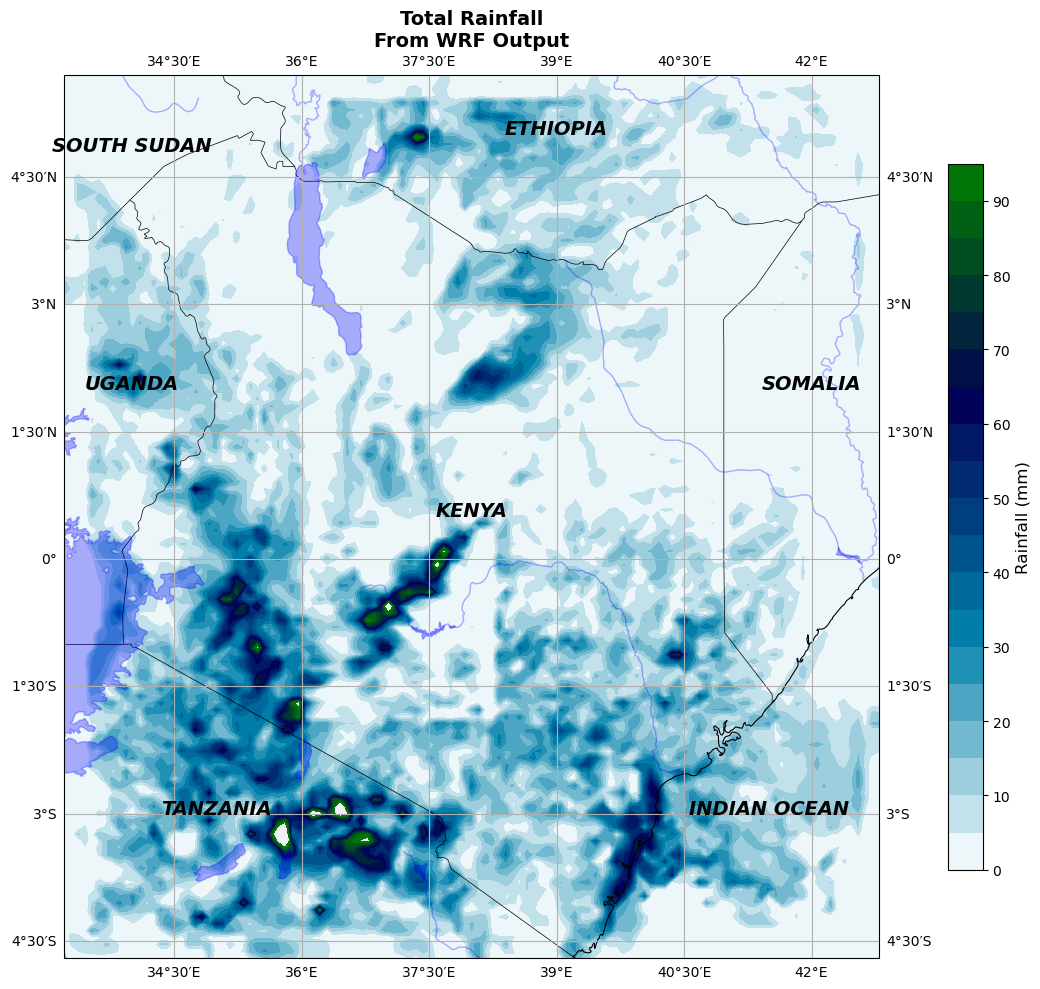

Rainfall map saved to './rainfall/rainfall_total.png'


In [11]:
# Create a single rainfall plot
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw=dict(projection=proj))

# Contourf for rainfall
rainfall_np = rainfall_total
contour = ax.contourf(lons_np, lats_np, rainfall_np, 
                       levels=np.arange(0, 100, 5),
                       cmap='ocean_r', 
                       transform=ccrs.PlateCarree())

# Add contour lines
# contour_lines = ax.contour(lons_np, lats_np, rainfall_np, 
#                            levels=np.arange(0, 100, 10),
#                            colors='black', 
#                            linewidths=0.5,
#                            alpha=0.4,
#                            transform=ccrs.PlateCarree())
# ax.clabel(contour_lines, inline=True, fontsize=8)

# Add colorbar
cbar = plt.colorbar(contour, ax=ax, shrink=0.8, pad=0.05)
cbar.set_label('Rainfall (mm)', fontsize=12)

# Add geographic features
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0, alpha=0.3)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="Blue")
ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)

# --- ADD COUNTRY AND OCEAN LABELS ---
# Syntax: ax.text(longitude, latitude, "Text", transform=ccrs.PlateCarree())
common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 14, 
    'fontstyle': 'italic',
    'fontweight': 'bold', 
    'ha': 'center'
}

ax.text(38.0, 0.5, "KENYA", **common_style)
ax.text(42.0, 2.0, "SOMALIA", **common_style)
ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
ax.text(34.0, 2.0, "UGANDA", **common_style)
ax.text(35.0, -3.0, "TANZANIA", **common_style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)


plt.title(f'Total Rainfall\nFrom WRF Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./rainfall/rainfall_total.png', dpi=300, bbox_inches='tight')
plt.show()

print("Rainfall map saved to './rainfall/rainfall_total.png'")

/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '



Cumulus Precipitation (RAINC):
  Min: -0.00 mm
  Max: 72.97 mm
  Mean: 8.27 mm

Non-Convective Precipitation (RAINNC):
  Min: 0.00 mm
  Max: 138.12 mm
  Mean: 1.90 mm


/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '



Total Rainfall:
  Min: 0.00 mm
  Max: 173.48 mm
  Mean: 10.17 mm


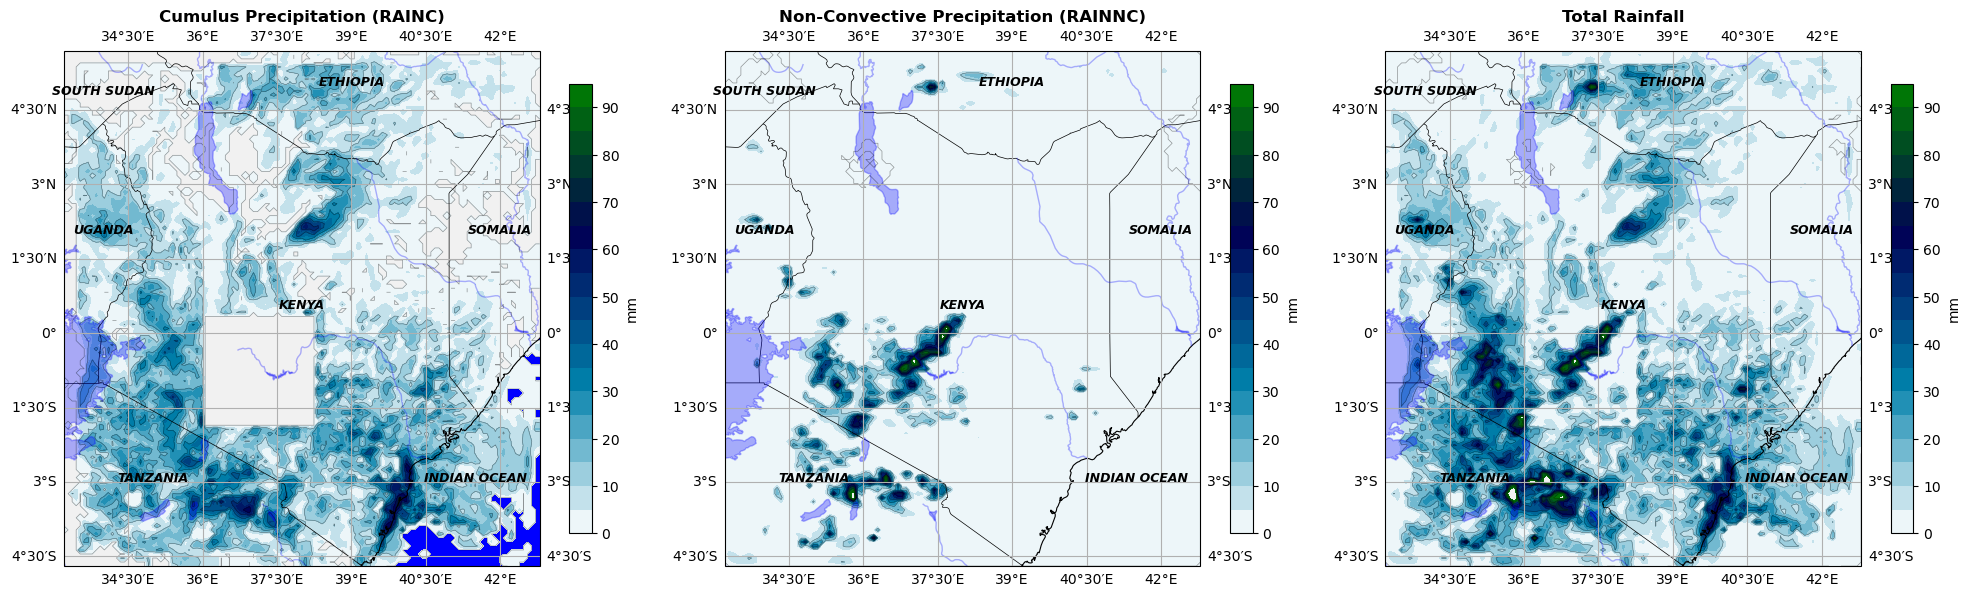


Rainfall comparison map saved to './rainfall/rainfall_comparison.png'


In [10]:
# Create a comparison plot with 3 subplots: RAINC, RAINNC, and Total
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw=dict(projection=proj))

data_list = [rainc, rainnc, rainfall_total]
titles = ['Cumulus Precipitation (RAINC)', 'Non-Convective Precipitation (RAINNC)', 'Total Rainfall']

for idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
    # Contourf
    contour = ax.contourf(lons_np, lats_np, data,
                         levels=np.arange(0, 100, 5),
                         cmap='ocean_r',
                         transform=ccrs.PlateCarree())
    
    # Add contour lines
    contour_lines = ax.contour(lons_np, lats_np, data,
                              levels=np.arange(0, 100, 10),
                              colors='black',
                              linewidths=0.5,
                              alpha=0.4,
                              transform=ccrs.PlateCarree())
    
    # Geographic features
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0, alpha=0.3)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.OCEAN, facecolor="Blue")
    ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
    ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)


    # --- ADD COUNTRY AND OCEAN LABELS ---
    common_style = {
    'transform': ccrs.PlateCarree(), 
    'fontsize': 9, 
    'fontstyle': 'italic',
    'fontweight': 'bold', 
    'ha': 'center'
    }

    ax.text(38.0, 0.5, "KENYA", **common_style)
    ax.text(42.0, 2.0, "SOMALIA", **common_style)
    ax.text(39.0, 5.0, "ETHIOPIA", **common_style)
    ax.text(34.0, 2.0, "UGANDA", **common_style)
    ax.text(35.0, -3.0, "TANZANIA", **common_style)
    ax.text(34.0, 4.8, "SOUTH SUDAN", **common_style)
    ax.text(41.5, -3.0, "INDIAN OCEAN", **common_style)
    
    # Colorbar
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('mm', fontsize=10)
    
    # Title
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Print statistics
    print(f"\n{title}:")
    print(f"  Min: {data.min():.2f} mm")
    print(f"  Max: {data.max():.2f} mm")
    print(f"  Mean: {data.mean():.2f} mm")

plt.tight_layout()
plt.savefig('./rainfall/rainfall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRainfall comparison map saved to './rainfall/rainfall_comparison.png'")

In [8]:
  # Ensure opencv-python is installed: pip install opencv-python

# 1. Setup Output Directory
output_dir = './rainfall'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Configuration
num_timesteps = min(25, len(ds.Time))
colormap = 'Blues'  # Selected from: YlGnBu, Blues, ocean_r
frame_files = []

print(f"Processing {num_timesteps} timesteps...")

# 2. Loop through timesteps to generate frames
for t in range(num_timesteps):
    # Extract rainfall data for the current timestep
    # Note: These are cumulative values in WRF
    rainc = ds['RAINC'].values[t]
    rainnc = ds['RAINNC'].values[t]
    rainfall_total = rainc + rainnc
    
    # Get the timestamp for the title
    time_str = str(ds.Time.values[t])[:19]
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), subplot_kw=dict(projection=proj))
    data_list = [rainc, rainnc, rainfall_total]
    titles = [f'RAINC (Convective)\n{time_str}', 
              f'RAINNC (Non-Convective)\n{time_str}', 
              f'Total Rainfall\n{time_str}']

    for idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
        # Plotting
        contour = ax.contourf(lons_np, lats_np, data,
                             levels=np.arange(0, 105, 5), # Consistent scale for animation
                             cmap=colormap,
                             transform=ccrs.PlateCarree(),
                             extend='max')
        
        # Add Geographic features
        ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
        ax.add_feature(cfeature.LAKES, facecolor="lightblue", alpha=0.3)
        
        # Gridlines (labels only on the leftmost plot to prevent overlap)
        gl = ax.gridlines(draw_labels=(idx == 0), dms=True, x_inline=False, y_inline=False, alpha=0.3)
        
        # Individual Colorbar
        cbar = plt.colorbar(contour, ax=ax, shrink=0.7, pad=0.05)
        cbar.set_label('mm')
        
        ax.set_title(title, fontsize=12, fontweight='bold')

    plt.tight_layout()
    
    # Save frame
    frame_path = os.path.join(output_dir, f'frame_{t:02d}.png')
    plt.savefig(frame_path, dpi=120, bbox_inches='tight')
    plt.close(fig) # Close to save memory
    frame_files.append(frame_path)
    
    if (t+1) % 5 == 0:
        print(f"  Generated {t+1}/{num_timesteps} frames...")


Processing 25 timesteps...
  Generated 5/25 frames...
  Generated 10/25 frames...
  Generated 15/25 frames...
  Generated 20/25 frames...
  Generated 25/25 frames...


In [9]:
# 3. Create Video Animation using imageio
import imageio

video_path = os.path.join(output_dir, 'rainfall_animation.mp4')
print(f"Compiling video to {video_path}...")

# Read frames and create video
images = []
for frame_file in frame_files:
    images.append(imageio.imread(frame_file))

# Write video with 2 frames per second
imageio.mimsave(video_path, images, fps=1)

print("Success! All frames and video are saved in the './rainfall/' folder.")
print(f"Video created: {video_path}")


Compiling video to ./rainfall/rainfall_animation.mp4...


/tmp/ipykernel_164339/1308394792.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(frame_file))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2584, 847) to (2592, 848) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x5ffc2a901bc0] Stream #0: not enough frames to estimate rate; consider increasing probesize


Success! All frames and video are saved in the './rainfall/' folder.
Video created: ./rainfall/rainfall_animation.mp4
